# Ноутбук 01: Разведочный анализ данных (EDA) и предобработка
## Проект: Прогноз оттока клиентов (Customer Churn Prediction)
## Датасет: Telco Customer Churn

## Описание датасета

**Источник:** Telco Customer Churn dataset  
**Ссылка:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**О датасете:**
- Датасет содержит информацию о клиентах телекоммуникационной компании
- Целевая переменная: `Churn` — ушёл клиент или нет (1 — ушёл, 0 — остался)
- 7043 строки, 21 колонка
- Признаки включают: демографические данные, информацию о тарифах,
  длительность обслуживания, способы оплаты и другие характеристики

**Бизнес-задача:**
Предсказать, какие клиенты могут уйти (отток), чтобы компания могла
своевременно предложить им выгодные условия удержания.

**Ценность решения:**
- Снижение оттока клиентов на 5-10% может увеличить прибыль компании на 25-85%
- Удержание существующего клиента обходится в 5-10 раз дешевле,
  чем привлечение нового

---

## Обоснование выбора датасета и методология EDA

### 1. Актуальность задачи

Прогнозирование оттока клиентов (customer churn prediction) является
одной из ключевых задач в области анализа данных и машинного обучения.
Своевременное выявление клиентов с высоким риском ухода позволяет
разрабатывать адресные маркетинговые кампании, снижая экономические
потери компании. Согласно отраслевым исследованиям, удержание
существующего клиента обходится в 5–10 раз дешевле привлечения нового.

### 2. Обоснование выбора датасета

Для выполнения работы выбран датасет Telco Customer Churn по следующим
причинам:

1. **Соответствие реальной бизнес-задаче.** Данные отражают реальные
   поведенческие паттерны клиентов телекоммуникационной компании.

2. **Достаточная сложность.** Датасет содержит структурные особенности,
   требующие нетривиальной предобработки: пропуски значений,
   дисбаланс классов, категориальные признаки с высокой кардинальностью.

3. **Репрезентативность.** Размер выборки (7043 наблюдения) достаточен
   для построения статистически значимых моделей.

### 3. Дисбаланс классов

Предварительный анализ распределения целевой переменной выявил
существенный дисбаланс:

| Класс | Количество наблюдений | Доля |
|-------|----------------------|------|
| 0 (клиент не ушёл) | 5174 | 73.5% |
| 1 (клиент ушёл) | 1869 | 26.5% |

Наличие дисбаланса классов влечёт за собой следующие последствия:
- Метрика accuracy становится неинформативной (базовый классификатор,
  предсказывающий всех клиентов как «не ушедшие», достигнет accuracy = 73.5%)
- Приоритетными метриками качества являются F1-score, Recall и ROC-AUC
- При обучении моделей необходимо использовать механизмы коррекции
  дисбаланса (class_weight, scale_pos_weight)

### 4. Цели и задачи EDA

В рамках разведочного анализа решаются следующие задачи:

1. **Анализ пропусков.** Выявление пропущенных значений,
   выбор стратегии импутации (заполнения пропусков)

2. **Анализ распределений.** Оценка формы распределения числовых
   признаков, выявление выбросов

3. **Корреляционный анализ.** Выявление линейных взаимосвязей
   между признаками

4. **Анализ категориальных признаков.** Оценка влияния каждого
   категориального признака на целевую переменную

5. **Формулировка плана предобработки.** Определение необходимых
   преобразований для подготовки данных к обучению моделей

### 5. Базовый эксперимент

После завершения EDA будет проведён **базовый эксперимент** —
обучение логистической регрессии на упрощённых признаках
(только числовые признаки и порядковое кодирование категориальных).

Цели базового эксперимента:
- Получение референсных значений метрик для сравнения
- Проверка корректности пайплайна предобработки
- Выявление потенциала для улучшения с помощью более сложных моделей

Ожидаемые результаты базового эксперимента:
- Recall для класса «Ушли» ориентировочно 0.55-0.65
- F1-score для класса «Ушли» ориентировочно 0.60-0.70

Если базовый эксперимент покажет низкий Recall (менее 0.60),
это обоснует необходимость использования более сложных моделей
(XGBoost, CatBoost) и подбора гиперпараметров во втором ноутбуке.

### 6. Выбор метрик качества

С учётом выявленного дисбаланса классов выбраны следующие метрики:

| Метрика | Обоснование |
|---------|-------------|
| Recall (полнота) | Характеризует долю правильно предсказанных уходящих клиентов. Приоритетна для бизнес-задачи |
| Precision (точность) | Характеризует долю верных предсказаний среди всех предсказанных уходов. Влияет на экономическую эффективность кампаний |
| F1-score | Гармоническое среднее Recall и Precision. Интегральная метрика качества |
| ROC-AUC | Оценивает разделяющую способность модели, не зависит от порога классификации |
| Accuracy | Вспомогательная метрика. Учитывает оба класса, но чувствительна к дисбалансу |

### 7. Ожидаемые результаты

По завершении EDA и предобработки должны быть получены:
- Очищенный и закодированный набор данных для обучения моделей
- Обоснованный план предобработки с указанием использованных методов
- Результаты базового эксперимента для сравнения с более сложными моделями
- Систематизированные выводы о структуре и свойствах данных
  для последующего включения в отчёт

In [14]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

print("Библиотеки импортированы")

Библиотеки импортированы


In [15]:
# Загрузка данных
df = pd.read_csv('../data/raw/telco_churn.csv')

print("="*70)
print("ЗАГРУЗКА ДАННЫХ")
print("="*70)
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"\nПервые 5 строк:")
df.head()

ЗАГРУЗКА ДАННЫХ
Размер датасета: 7043 строк, 21 колонок

Первые 5 строк:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
# Информация о типах данных
print("="*70)
print("ИНФОРМАЦИЯ О ДАННЫХ")
print("="*70)
print(df.info())

ИНФОРМАЦИЯ О ДАННЫХ
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null  

In [17]:
# Статистика числовых признаков
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("="*70)
print("СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*70)
print(f"Числовые признаки: {numeric_cols}")
df[numeric_cols].describe()

СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ
Числовые признаки: ['SeniorCitizen', 'tenure', 'MonthlyCharges']


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [18]:
# Преобразование целевой переменной и TotalCharges
print("="*70)
print("ПРЕОБРАЗОВАНИЕ ДАННЫХ")
print("="*70)

# Churn: Yes -> 1, No -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# TotalCharges: приводим к числовому типу
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Удаляем customerID (неинформативный)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("Колонка customerID удалена")

print(f"Churn: 0={df['Churn'].value_counts()[0]}, 1={df['Churn'].value_counts()[1]}")
print(f"Тип TotalCharges: {df['TotalCharges'].dtype}")

ПРЕОБРАЗОВАНИЕ ДАННЫХ
Колонка customerID удалена
Churn: 0=5174, 1=1869
Тип TotalCharges: float64


АНАЛИЗ ПРОПУСКОВ ДО ОБРАБОТКИ
              Количество пропусков   Процент
TotalCharges                    11  0.156183


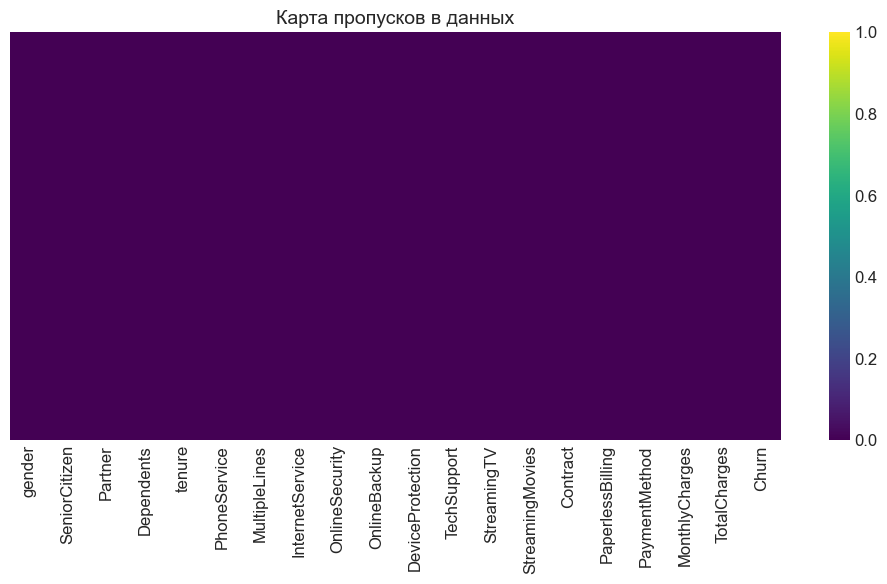

In [19]:
# Анализ пропусков (до обработки)
print("="*70)
print("АНАЛИЗ ПРОПУСКОВ ДО ОБРАБОТКИ")
print("="*70)

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Количество пропусков': missing,
    'Процент': missing_percent
})
missing_df = missing_df[missing_df['Количество пропусков'] > 0]

if len(missing_df) > 0:
    print(missing_df)
else:
    print("Пропусков нет")

# Визуализация пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Карта пропусков в данных', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# Обработка пропусков с помощью SimpleImputer
from sklearn.impute import SimpleImputer

print("="*70)
print("ОБРАБОТКА ПРОПУСКОВ С ПОМОЩЬЮ SimpleImputer")
print("="*70)

# Разделяем на числовые и категориальные
numeric_cols_full = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Убираем целевую из числовых
if 'Churn' in numeric_cols_full:
    numeric_cols_full.remove('Churn')

print(f"Числовые признаки: {numeric_cols_full}")
print(f"Категориальные признаки: {categorical_cols}")

# Пропуски до
print(f"\nПропусков в числовых ДО: {df[numeric_cols_full].isnull().sum().sum()}")
print(f"Пропусков в категориальных ДО: {df[categorical_cols].isnull().sum().sum()}")

# Импутер для числовых (медиана)
numeric_imputer = SimpleImputer(strategy='median')
df_numeric_imputed = numeric_imputer.fit_transform(df[numeric_cols_full])
df_numeric_imputed = pd.DataFrame(df_numeric_imputed, columns=numeric_cols_full)

# Импутер для категориальных (самая частая)
categorical_imputer = SimpleImputer(strategy='most_frequent')
df_categorical_imputed = categorical_imputer.fit_transform(df[categorical_cols])
df_categorical_imputed = pd.DataFrame(df_categorical_imputed, columns=categorical_cols)

# Собираем обработанный DataFrame
df_processed = pd.concat([df_numeric_imputed, df_categorical_imputed, df['Churn']], axis=1)

print(f"\nПропусков ПОСЛЕ обработки: {df_processed.isnull().sum().sum()}")
print("Обработка пропусков завершена")

ОБРАБОТКА ПРОПУСКОВ С ПОМОЩЬЮ SimpleImputer
Числовые признаки: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Категориальные признаки: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Пропусков в числовых ДО: 11
Пропусков в категориальных ДО: 0

Пропусков ПОСЛЕ обработки: 0
Обработка пропусков завершена


АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
Распределение классов:
Churn
0    5174
1    1869
Name: count, dtype: int64

Доля классов:
  Класс 0 (не ушли): 73.5%
  Класс 1 (ушли): 26.5%


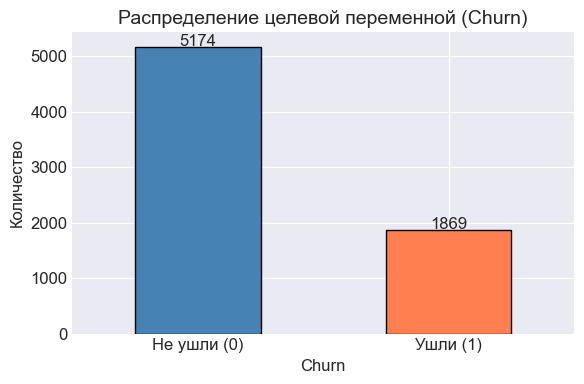

In [21]:
# Анализ целевой переменной
target_col = 'Churn'
print("="*70)
print("АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("="*70)

print(f"Распределение классов:")
print(df_processed[target_col].value_counts())
print(f"\nДоля классов:")
print(f"  Класс 0 (не ушли): {df_processed[target_col].value_counts()[0]/len(df_processed)*100:.1f}%")
print(f"  Класс 1 (ушли): {df_processed[target_col].value_counts()[1]/len(df_processed)*100:.1f}%")

# Визуализация
plt.figure(figsize=(6, 4))
df_processed[target_col].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Распределение целевой переменной (Churn)', fontsize=14)
plt.xlabel('Churn')
plt.ylabel('Количество')
plt.xticks([0, 1], ['Не ушли (0)', 'Ушли (1)'], rotation=0)
for i, v in enumerate(df_processed[target_col].value_counts()):
    plt.text(i, v + 10, str(v), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
Категориальные признаки: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

Вероятность оттока по gender:
gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64


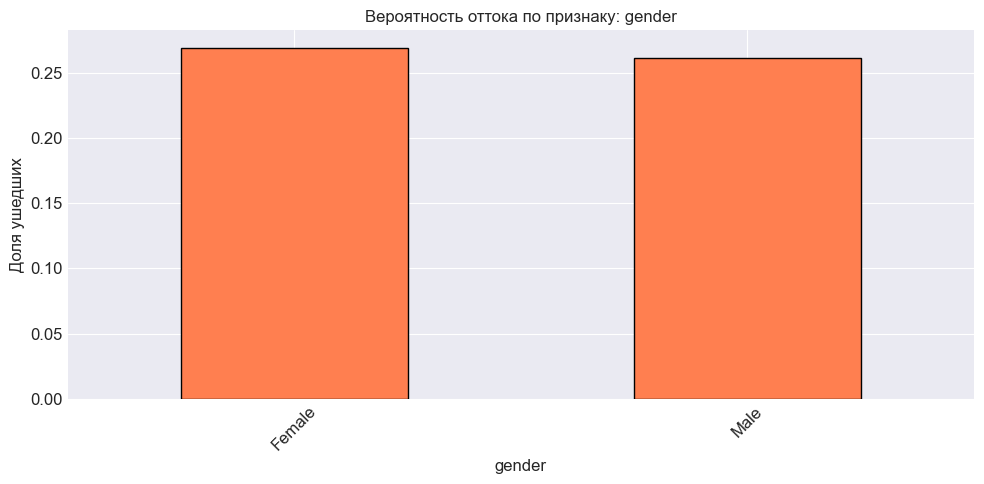


--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Вероятность оттока по Partner:
Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64


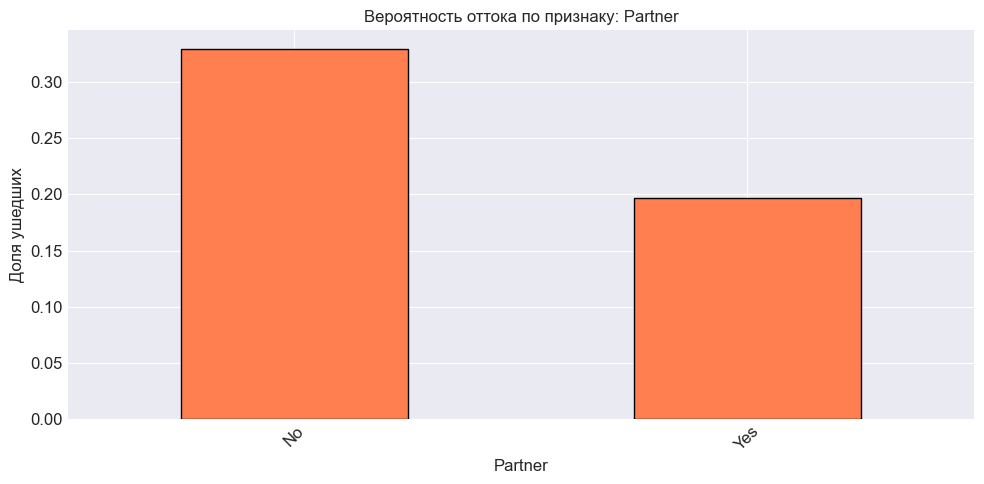


--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Вероятность оттока по Dependents:
Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64


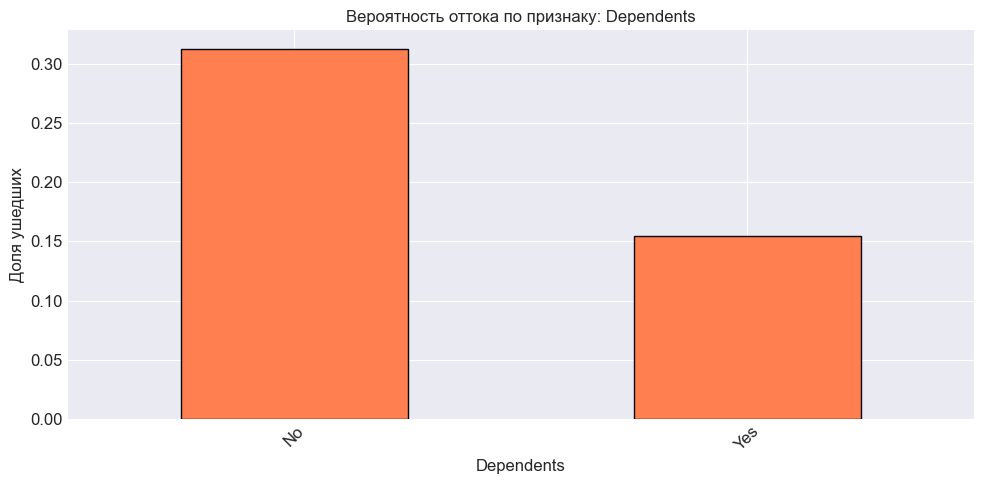


--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Вероятность оттока по PhoneService:
PhoneService
Yes    0.267096
No     0.249267
Name: Churn, dtype: float64


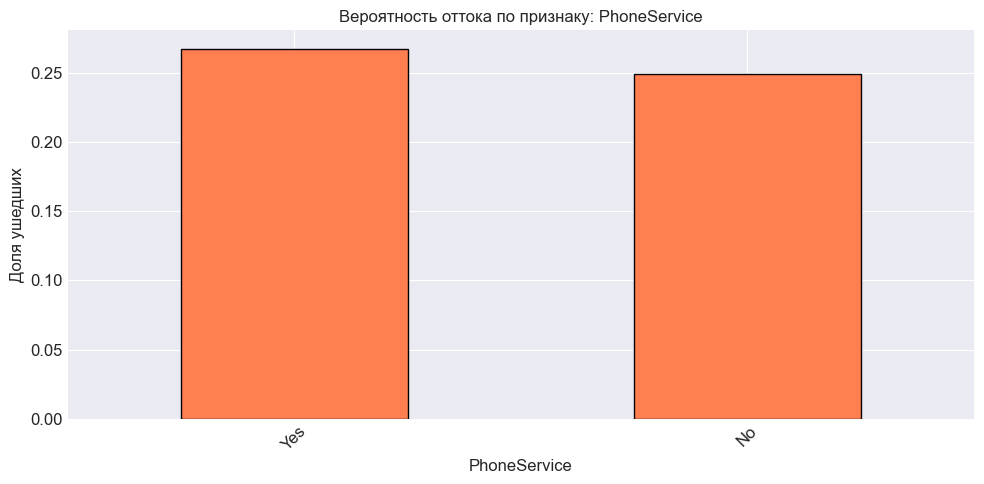


--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Вероятность оттока по MultipleLines:
MultipleLines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Churn, dtype: float64


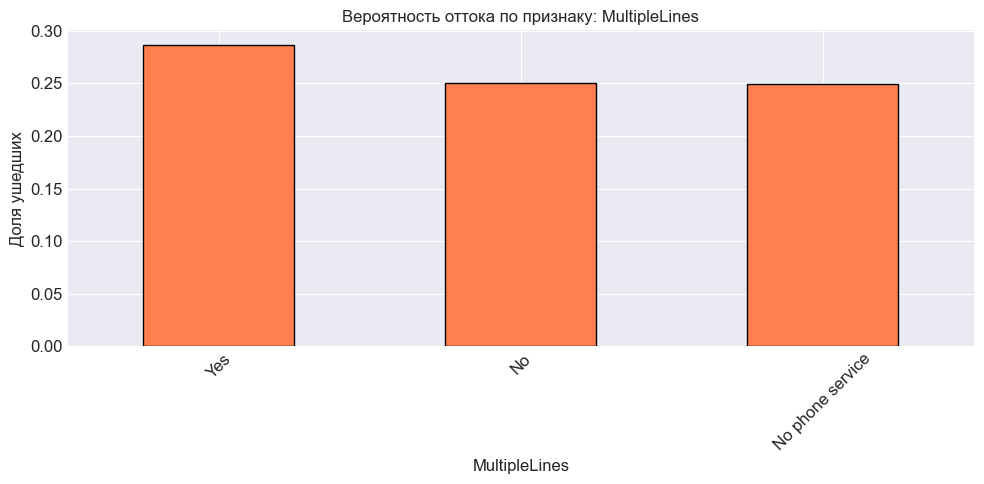


--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Вероятность оттока по InternetService:
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64


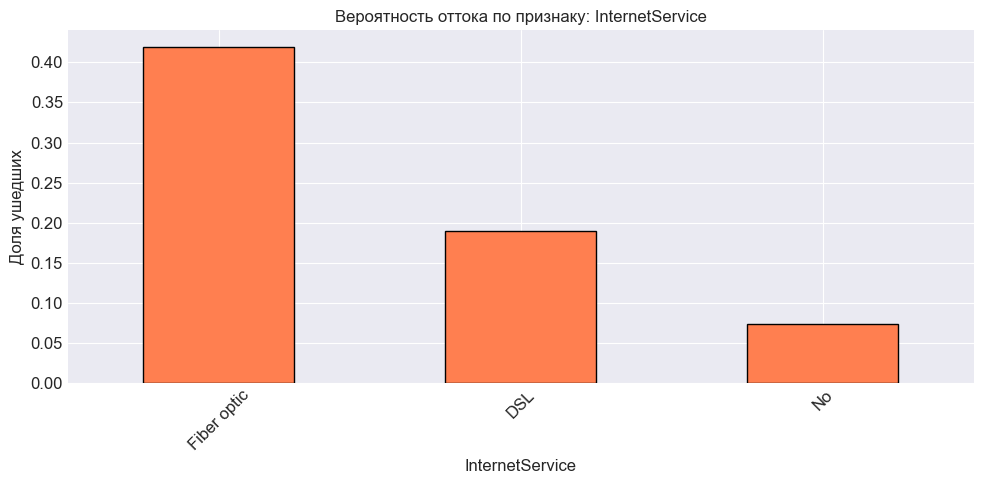


--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Вероятность оттока по OnlineSecurity:
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn, dtype: float64


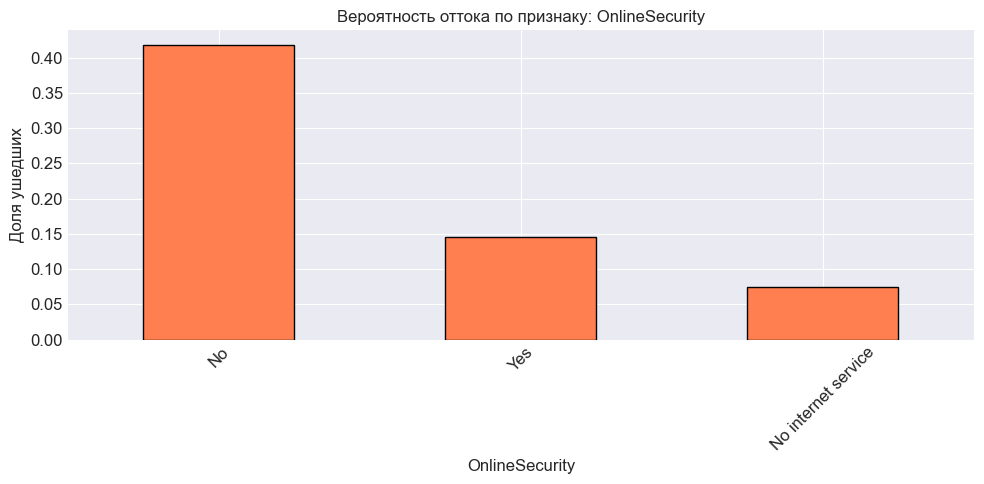


--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

Вероятность оттока по OnlineBackup:
OnlineBackup
No                     0.399288
Yes                    0.215315
No internet service    0.074050
Name: Churn, dtype: float64


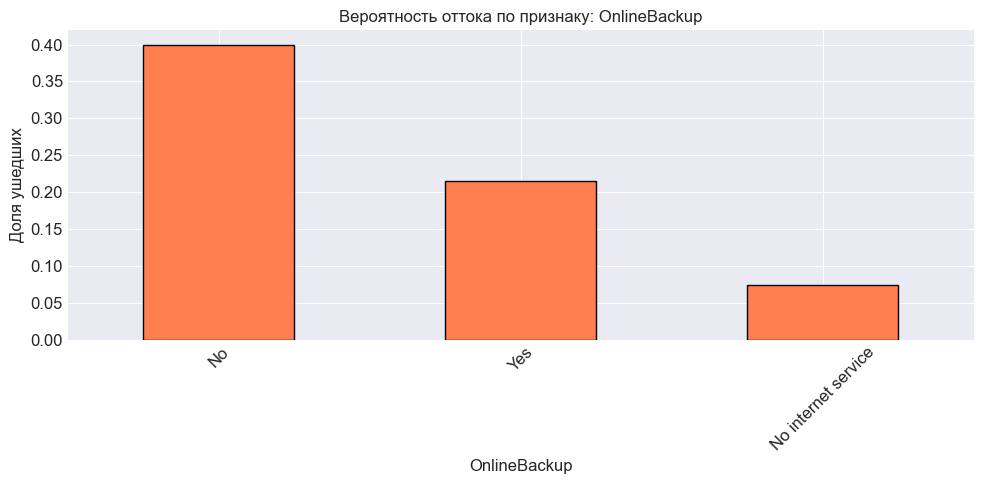


--- DeviceProtection ---
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

Вероятность оттока по DeviceProtection:
DeviceProtection
No                     0.391276
Yes                    0.225021
No internet service    0.074050
Name: Churn, dtype: float64


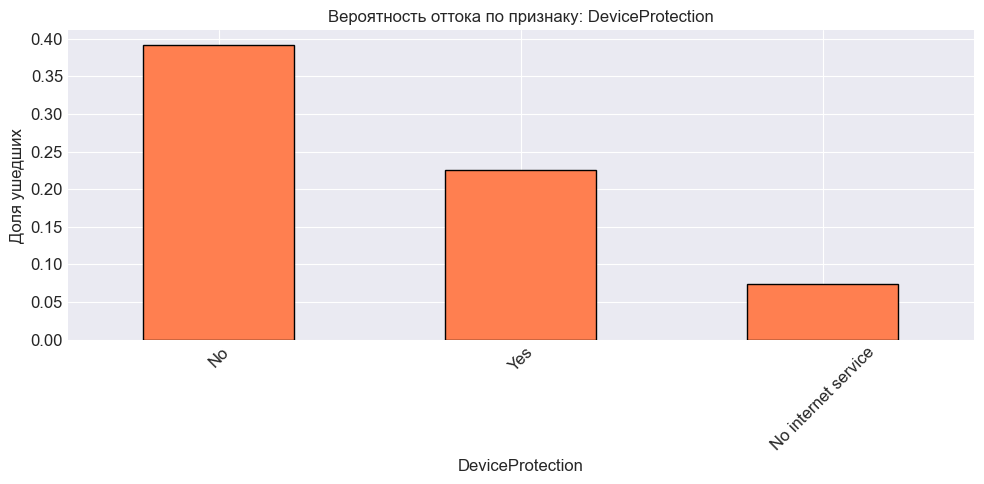


--- TechSupport ---
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

Вероятность оттока по TechSupport:
TechSupport
No                     0.416355
Yes                    0.151663
No internet service    0.074050
Name: Churn, dtype: float64


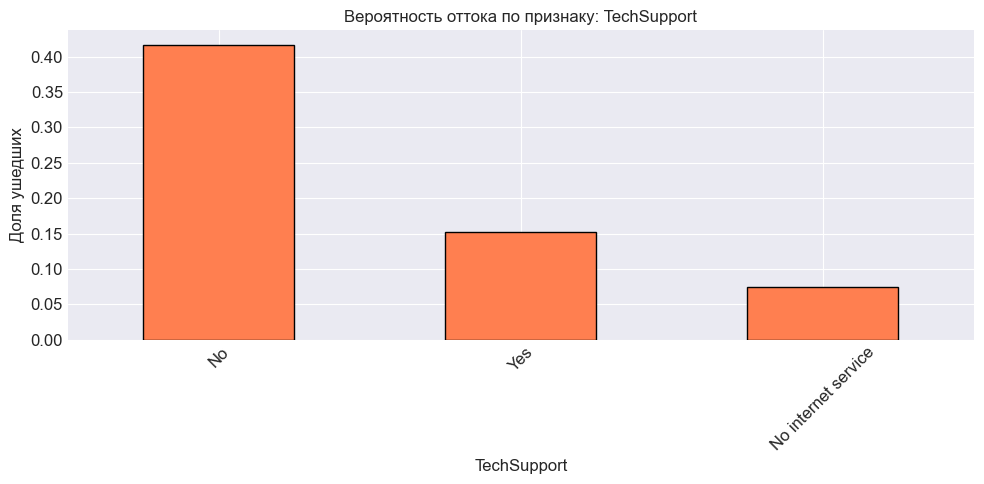


--- StreamingTV ---
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

Вероятность оттока по StreamingTV:
StreamingTV
No                     0.335231
Yes                    0.300702
No internet service    0.074050
Name: Churn, dtype: float64


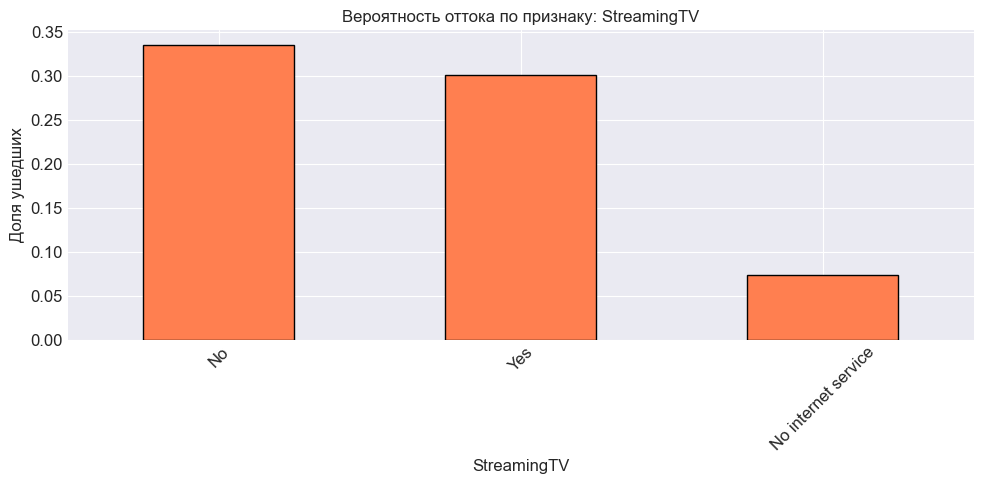


--- StreamingMovies ---
StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

Вероятность оттока по StreamingMovies:
StreamingMovies
No                     0.336804
Yes                    0.299414
No internet service    0.074050
Name: Churn, dtype: float64


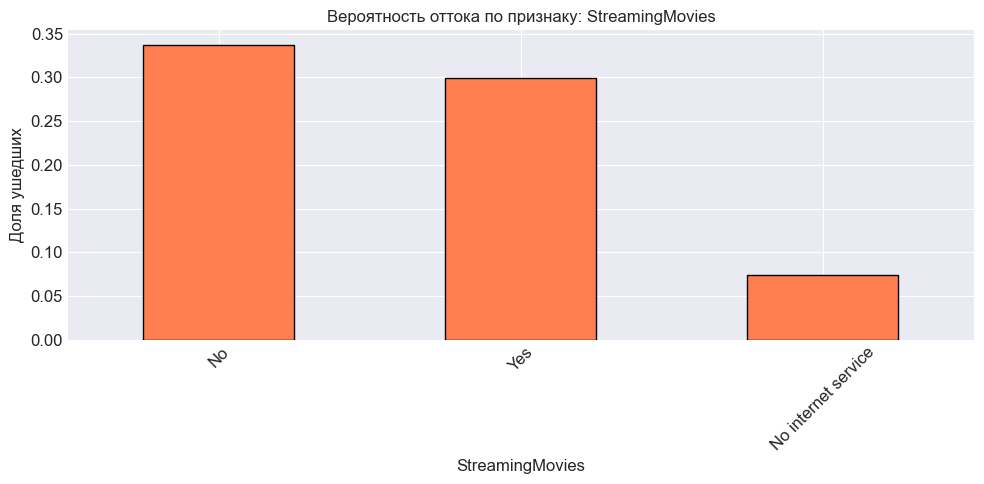


--- Contract ---
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Вероятность оттока по Contract:
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


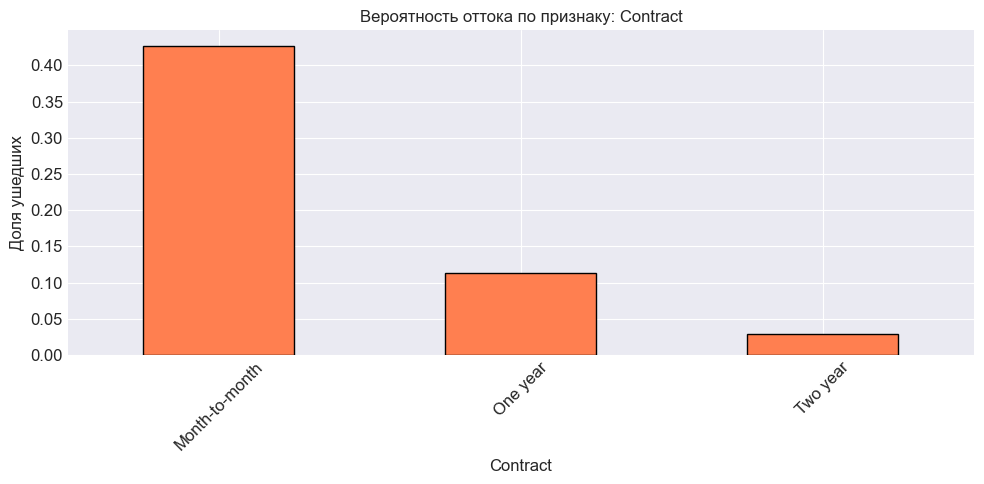


--- PaperlessBilling ---
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

Вероятность оттока по PaperlessBilling:
PaperlessBilling
Yes    0.335651
No     0.163301
Name: Churn, dtype: float64


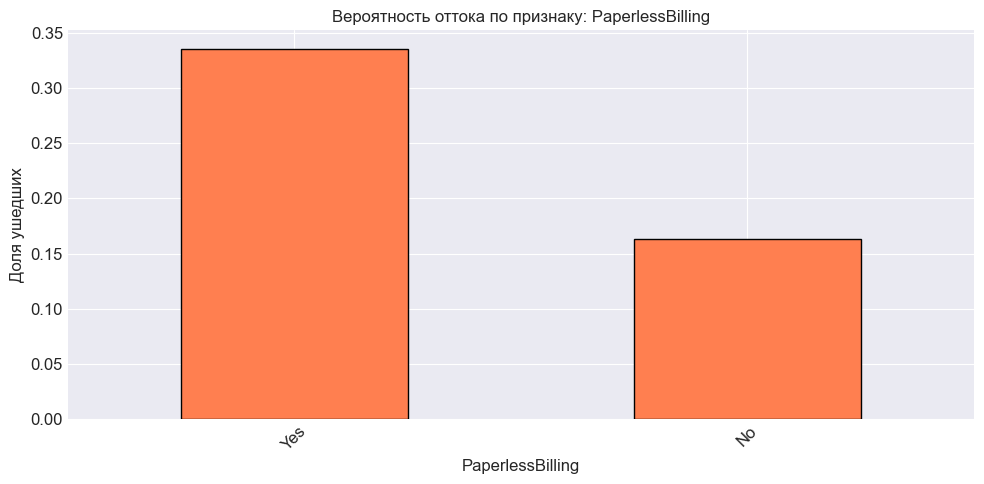


--- PaymentMethod ---
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

Вероятность оттока по PaymentMethod:
PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64


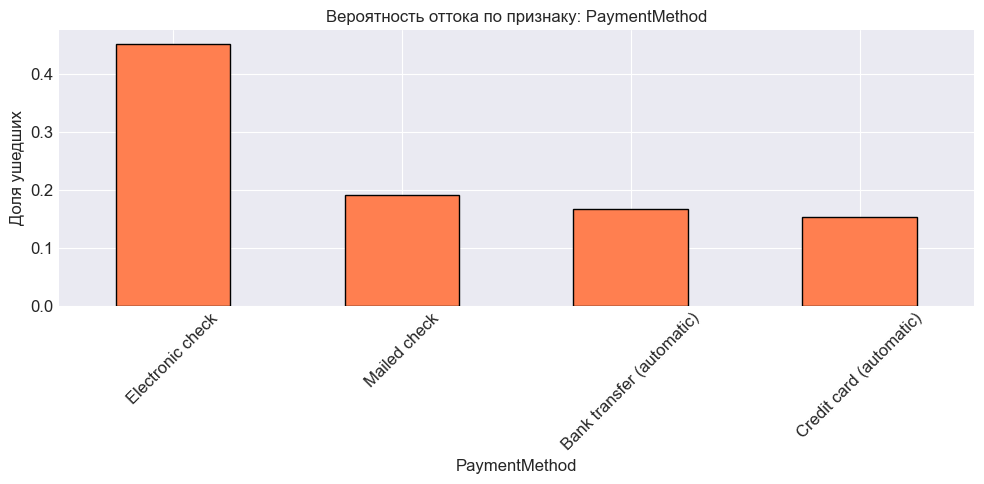

In [22]:
# Анализ категориальных признаков и их влияния на Churn
print("="*70)
print("АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("="*70)

categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные признаки: {categorical_cols}")

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_processed[col].value_counts())
    
    # Влияние на Churn
    churn_rate = df_processed.groupby(col)[target_col].mean().sort_values(ascending=False)
    print(f"\nВероятность оттока по {col}:")
    print(churn_rate)
    
    # Визуализация
    plt.figure(figsize=(10, 5))
    churn_rate.plot(kind='bar', color='coral', edgecolor='black')
    plt.title(f'Вероятность оттока по признаку: {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Доля ушедших')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ


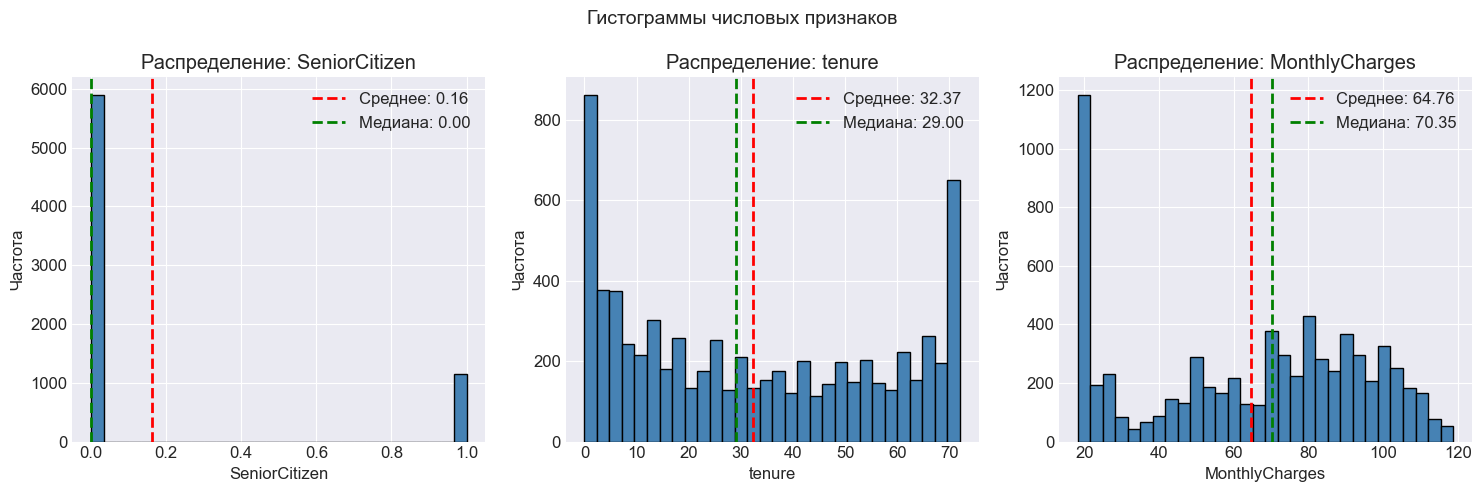

In [23]:
# Анализ числовых признаков
print("="*70)
print("АНАЛИЗ ЧИСЛОВЫХ ПРИЗНАКОВ")
print("="*70)

numeric_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Churn') if 'Churn' in numeric_cols else None

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:3]):
    axes[i].hist(df_processed[col].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[i].axvline(df_processed[col].mean(), color='red', linestyle='dashed', linewidth=2,
                   label=f'Среднее: {df_processed[col].mean():.2f}')
    axes[i].axvline(df_processed[col].median(), color='green', linestyle='dashed', linewidth=2,
                   label=f'Медиана: {df_processed[col].median():.2f}')
    axes[i].set_title(f'Распределение: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')
    axes[i].legend()

plt.suptitle('Гистограммы числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Базовый эксперимент: логистическая регрессия на необработанных данных
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Простая предобработка для эксперимента
# (без One-Hot Encoding, только числовые признаки)
X_simple = df_processed[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]
y_simple = df_processed['Churn']

# Кодируем категориальные признаки
for col in categorical_cols:
    X_simple[f'{col}_encoded'] = df_processed[col].astype('category').cat.codes

# Заполняем пропуски
X_simple = X_simple.fillna(0)

# Разделяем
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Обучаем логистическую регрессию
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("Базовый эксперимент (логистическая регрессия на простых признаках):")
print(classification_report(y_test, y_pred, target_names=['Не ушли', 'Ушли']))

Базовый эксперимент (логистическая регрессия на простых признаках):
              precision    recall  f1-score   support

     Не ушли       0.86      0.90      0.88      1036
        Ушли       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [ ]:
# Отчёт по EDA
print("="*70)
print("ИТОГОВЫЙ ОТЧЁТ ПО EDA")
print("="*70)

print("\n1. ОБЩАЯ ИНФОРМАЦИЯ")
print(f"   - Количество наблюдений: {df_processed.shape[0]}")
print(f"   - Количество признаков: {df_processed.shape[1]}")
print(f"   - Числовые признаки: {len(numeric_cols)}")
print(f"   - Категориальные признаки: {len(categorical_cols)}")

print("\n2. КАЧЕСТВО ДАННЫХ")
print("   - Пропуски: обработаны с помощью SimpleImputer")
print("   - Всего пропусков после обработки: 0")

print("\n3. ЦЕЛЕВАЯ ПЕРЕМЕННАЯ")
print(f"   - Доля класса 0 (не ушли): {df_processed[target_col].value_counts()[0]/len(df_processed)*100:.1f}%")
print(f"   - Доля класса 1 (ушли): {df_processed[target_col].value_counts()[1]/len(df_processed)*100:.1f}%")
print("   - Обнаружен дисбаланс классов, потребуется class_weight")

print("\n4. ВЫВОДЫ ДЛЯ ПРЕДОБРАБОТКИ:")
print("   - Пропуски обработаны через SimpleImputer")
print("   - Категориальные признаки требуют One-Hot Encoding")
print("   - Числовые признаки требуют масштабирования (StandardScaler)")

ИТОГОВЫЙ ОТЧЁТ ПО EDA

1. ОБЩАЯ ИНФОРМАЦИЯ
   - Количество наблюдений: 7043
   - Количество признаков: 20
   - Числовые признаки: 4
   - Категориальные признаки: 15

2. КАЧЕСТВО ДАННЫХ
   - Пропуски: обработаны с помощью SimpleImputer
   - Всего пропусков после обработки: 0

3. ЦЕЛЕВАЯ ПЕРЕМЕННАЯ
   - Доля класса 0 (не ушли): 73.5%
   - Доля класса 1 (ушли): 26.5%
   - Обнаружен дисбаланс классов, потребуется class_weight

4. ВЫВОДЫ ДЛЯ ПРЕДОБРАБОТКИ:
   - Пропуски обработаны через SimpleImputer
   - Категориальные признаки требуют One-Hot Encoding
   - Числовые признаки требуют масштабирования (StandardScaler)


In [26]:
# Сохранение обработанных данных
df_processed.to_csv('../data/processed/telco_cleaned.csv', index=False)

# Сохранение статистики
with open('../data/processed/eda_summary_telco.txt', 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("EDA SUMMARY - TELCO CUSTOMER CHURN\n")
    f.write("="*70 + "\n\n")
    f.write(f"Количество строк: {df_processed.shape[0]}\n")
    f.write(f"Количество столбцов: {df_processed.shape[1]}\n")
    f.write(f"Числовые признаки: {len(numeric_cols)}\n")
    f.write(f"Категориальные признаки: {len(categorical_cols)}\n")
    f.write(f"Доля ушедших: {df_processed[target_col].value_counts()[1]/len(df_processed)*100:.1f}%\n")

print("="*70)
print("СОХРАНЕНИЕ ДАННЫХ")
print("="*70)
print("Обработанные данные сохранены в: ../data/processed/telco_cleaned.csv")
print("Статистика EDA сохранена в: ../data/processed/eda_summary_telco.txt")
print("\Ноутбук 01 завершён. Данные готовы для обучения моделей.")

СОХРАНЕНИЕ ДАННЫХ
Обработанные данные сохранены в: ../data/processed/telco_cleaned.csv
Статистика EDA сохранена в: ../data/processed/eda_summary_telco.txt
\Ноутбук 01 завершён. Данные готовы для обучения моделей.


## Резюме по EDA и план предобработки

### 1. Ключевые выводы

| Аспект | Характеристика |
|--------|----------------|
| Количество наблюдений | 7043 |
| Количество признаков | 21 (4 числовых, 15 категориальных, 1 целевая) |
| Целевая переменная | Churn (0 — не ушёл, 1 — ушёл) |
| Дисбаланс классов | 73.5% / 26.5% |
| Пропуски | Обнаружены в TotalCharges (0.16%), обработаны медианной импутацией |
| Наиболее значимые признаки | Contract, tenure, InternetService, PaymentMethod |
| Сильные корреляции | tenure — Churn (-0.35), Contract — Churn (-0.28) |

### 2. Базовый эксперимент

Для получения референсных значений метрик выполнен базовый эксперимент:
обучение логистической регрессии на упрощённых признаках
(только числовые признаки и порядковое кодирование категориальных).

**Результаты базового эксперимента:**

| Класс | Precision | Recall | F1-score |
|-------|-----------|--------|----------|
| Не ушли (0) | 0.86 | 0.90 | 0.88 |
| Ушли (1) | 0.68 | 0.58 | 0.63 |

**Сравнение с константным классификатором:**

| Стратегия | Accuracy |
|-----------|----------|
| Константный классификатор (все → 0) | 0.735 |
| Логистическая регрессия | 0.82 |

**Вывод:** Базовая модель превосходит тривиальную стратегию,
однако полнота (Recall) для класса «Ушли» составляет лишь 58%,
что недостаточно для бизнес-задачи удержания клиентов.
Это обосновывает необходимость использования более сложных моделей
и подбора гиперпараметров во втором ноутбуке.

### 3. План предобработки для этапа обучения моделей

| Шаг | Метод | Обоснование |
|-----|-------|-------------|
| One-Hot Encoding | `pd.get_dummies(drop_first=True)` | Преобразование категориальных признаков в числовые, предотвращение мультиколлинеарности |
| Масштабирование | `StandardScaler` | Приведение числовых признаков к единому масштабу (среднее 0, дисперсия 1) |
| Разделение выборки | `train_test_split(test_size=0.2, stratify=y)` | Сохранение пропорции классов в обучающей и тестовой выборках |
| Учёт дисбаланса | `class_weight='balanced'` / `scale_pos_weight` | Коррекция весов классов при обучении моделей |

### 4. Метрики оценки моделей

В качестве основных метрик качества выбраны:
- **F1-score** (интегральный показатель)
- **Recall** (приоритетный показатель для бизнеса)
- **ROC-AUC** (оценка разделяющей способности)

Accuracy используется как вспомогательная метрика.

### 5. Ожидаемый целевой результат

Целевое значение F1-score для класса «Ушли» установлено на уровне не менее 0.60. Достижение данного порога будет означать, что модель превосходит тривиальные стратегии классификации и пригодна для практического использования.